In [622]:
# to autoimport edited modules in the notebook
%load_ext autoreload
%autoreload 2

from grsc_cb_model import GRSC_CB_Model
from grsc_cb_instance import GRSC_CB_Instance
import numpy as np
from scipy.spatial import Delaunay, ConvexHull
import networkx as nx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [623]:
# number of land parcels
n = 80
# number of species
m = 10
# number of max connected areas
k = 1
# range of habitat suitability function
w_min, w_max = 20, 100
# range of costs
c_min, c_max = 1, 100
# lambda percentage threshold
lambda_threshold = 0.05
# buffer size
d = 1
# tau
tau = 0.5

External nodes: [0, 32, 2, 67, 36, 4, 38, 43, 47, 48, 54, 57, 31]


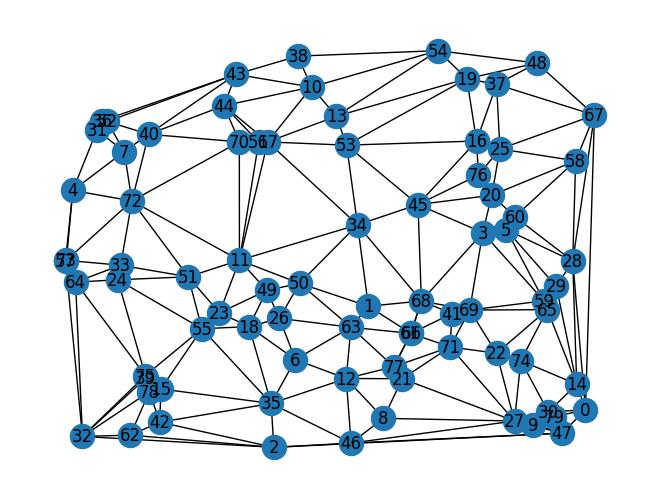

In [624]:
# generate a random instance Delunay graph
points = np.random.rand(n, 2)
tri = Delaunay(points)

G = nx.Graph()
G.add_nodes_from(range(len(points)))

# for each node, it connects it to its neighbors using Delaunay triangulation
for simplex in tri.simplices:
    i, j, h = simplex
    G.add_edge(i, j)
    G.add_edge(j, h)
    G.add_edge(i, h)

# determines the set of external nodes  
external_nodes = set(ConvexHull(points).vertices)
nx.draw(G, points, with_labels=True)
print(f"External nodes: {[int(i) for i in external_nodes]}")

In [625]:
# costs of land parcels
c = {i: np.random.randint(c_min, c_max + 1) for i in G.nodes}

In [626]:
# specie definition
S_1 = list(range(m//3))
S_2 = list(range(m//3, m))
P_1 = len(S_1)
P_2 = len(S_2)

# habitat suitability score function
w = {}
for s in S_1 + S_2:
    prob_zero = 0.2 if s in S_1 else 0.1
    for i in G.nodes:
        if i in external_nodes and s in S_1:
            w[(i, s)] = 0
        elif np.random.rand() < prob_zero:
            w[(i, s)] = 0
        else:
            w[(i, s)] = np.random.randint(w_min, w_max + 1)
            
# suitability quota
lambda_s = {s: lambda_threshold * sum(w[(i, s)] for i in G.nodes) for s in S_1 + S_2}

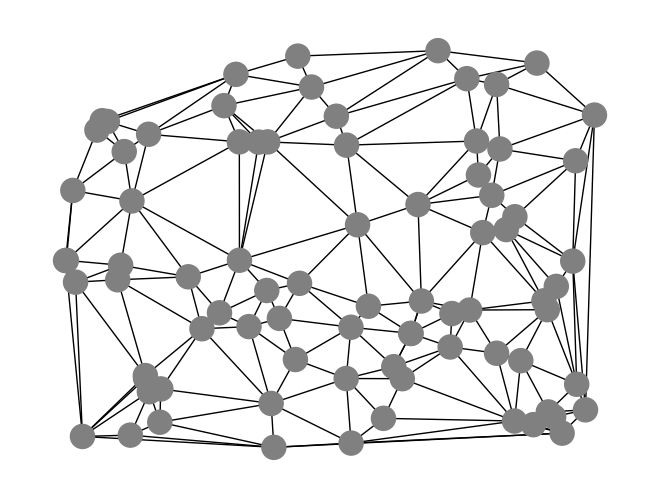

In [627]:
# toy instance
V, E = set(G.nodes), set(G.edges)
instance = GRSC_CB_Instance(V, E, points, 
                            S_1, S_2, P_1, P_2, 
                            k, w, lambda_s, c, d)

instance.draw_graph()


GRSC_CB_Instance(|V|=80, |E|=224, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 24.0
Nodes in the reserve (x): [15, 16, 18, 30, 77]
Nodes in the core (z): [15, 18, 30]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): []


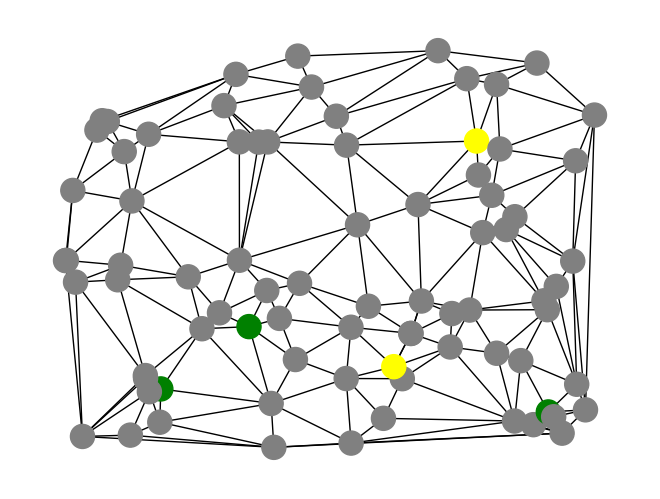

In [628]:
print(instance)
model = GRSC_CB_Model(instance)
model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=80, |E|=224, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
Status: 2 Optimal
Objective: 339.0
Nodes in the reserve (x): [0, 9, 14, 22, 27, 30, 47, 65, 74, 79]
Nodes in the core (z): [9, 30, 74]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): []


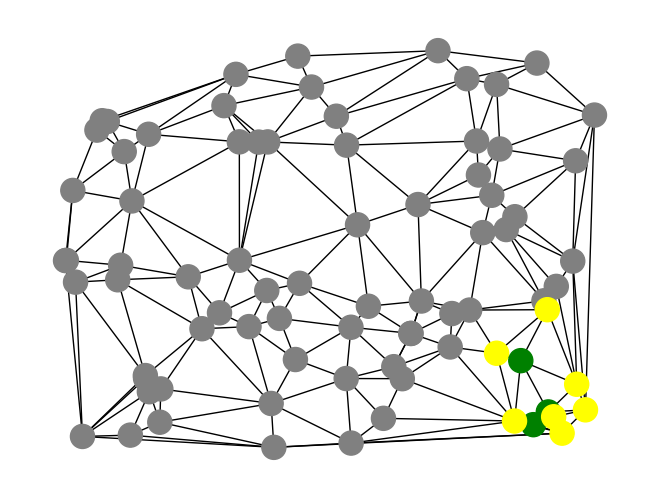

In [629]:
print(instance)
model = GRSC_CB_Model(instance, B=True)
model.solve()
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=80, |E|=224, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
	 * Added constraints: {'corecon-int': 90, 'corecon-frc': 297, 'cover': 0, 'scc-s1': 0, 'scc-s2': 0}
Status: 2 Optimal
Objective: 88.0
Nodes in the reserve (x): [6, 12, 18, 21, 23, 77]
Nodes in the core (z): [6, 12, 18, 21, 23, 77]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [6]


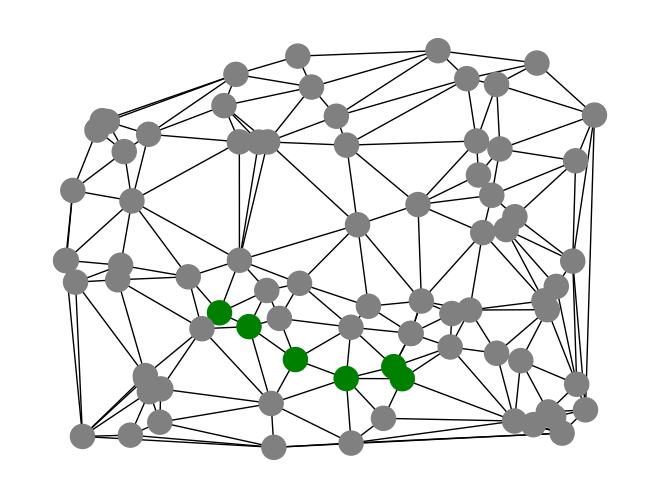

In [634]:
print(instance)
model = GRSC_CB_Model(instance, C=True)
model.solve(verbose=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=80, |E|=224, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
	 * Initial solution found with Construction Heuristic. Nodes: {np.int32(70), 7, 40, np.int32(72), 10, 43, 44, 17, np.int32(52), np.int32(56)}
	 * Solution of Primal Heuristic injected. Nodes: {1, np.int32(34), np.int32(66), np.int32(68), 6, 12, np.int32(77), 50, 26, 61, 63}
Status: 2 Optimal
Objective: 339.0
Nodes in the reserve (x): [0, 9, 14, 22, 27, 30, 47, 65, 74, 79]
Nodes in the core (z): [9, 30, 74, 79]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [74]


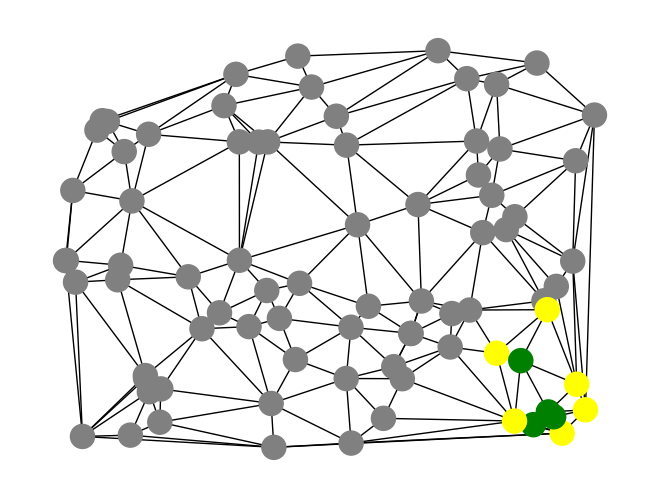

In [631]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=80, |E|=224, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
	 * Initial solution found with Construction Heuristic. Nodes: {0, np.int32(67), 9, np.int32(74), 14, np.int32(79), np.int32(47), np.int32(27), np.int32(28), np.int32(30)}
	 * Solution of Primal Heuristic injected. Nodes: {1, np.int32(34), np.int32(66), np.int32(68), 6, 12, np.int32(77), 50, 26, 61, 63}
Status: 2 Optimal
Objective: 339.0
Nodes in the reserve (x): [0, 9, 14, 22, 27, 30, 47, 65, 74, 79]
Nodes in the core (z): [9, 30, 74, 79]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [74]


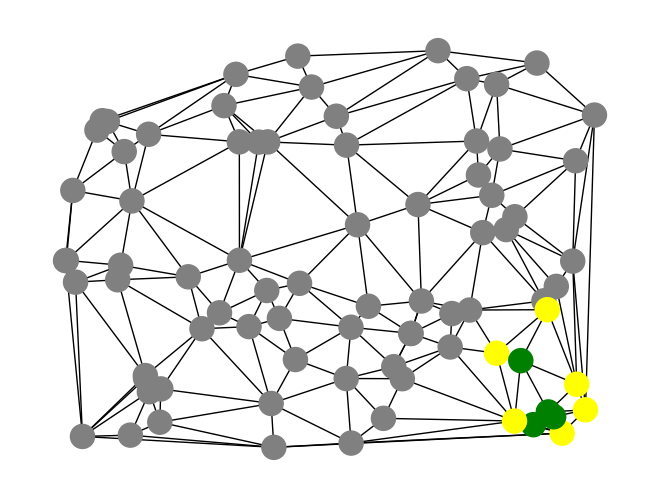

In [632]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True, cp_heuristic=True)
model.print_solution()
model.print_graph()

GRSC_CB_Instance(|V|=80, |E|=224, |S1|=3, |S2|=7, P1=3, P2=7, k=1, d=1)
Set parameter LazyConstraints to value 1
	 * Initial solution found with Construction Heuristic. Nodes: {np.int32(64), 33, 4, np.int32(72), np.int32(73), np.int32(51), 24, 57}
	 * LB heuristic completed. Best objective: 328.00, Iterations: 4
Status: 2 Optimal
Objective: 339.0
Nodes in the reserve (x): [0, 9, 14, 22, 27, 30, 47, 65, 74, 79]
Nodes in the core (z): [9, 30, 74, 79]
Species protected (u): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
r-arc-node separators (y): [9]


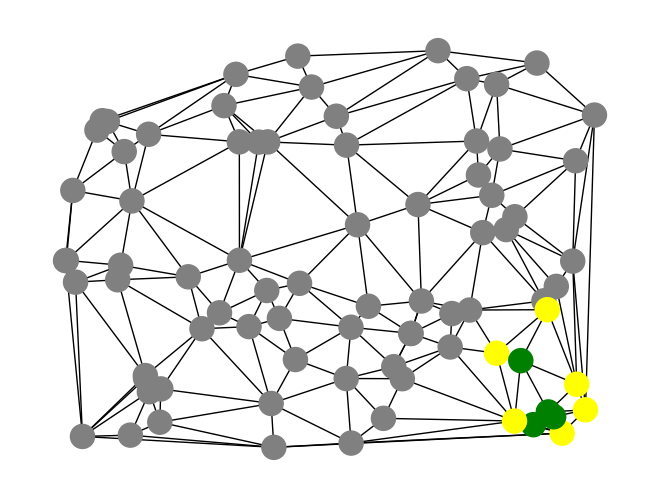

In [633]:
print(instance)
model = GRSC_CB_Model(instance, B=True, C=True)
result = model.solve(basic=True, cp_heuristic=True, lb_heuristic=True, verbose=True)
model.print_solution()
model.print_graph()